# Stage 0 — Study Area Boundaries

Defines the two study extents used throughout the project:

- **Mole Creek** — the local case-study area, built and tested first
- **Tasmania** — the statewide extent, used once the method is frozen at Mole Creek

All outputs are reprojected to **EPSG:7855 (GDA2020 / MGA Zone 55)** —
the common analysis CRS for the whole project (see README "Workflow /
Methodology Reference"). Note the source data is natively GDA94/MGA55
(EPSG:28355); reprojecting to GDA2020 is a deliberate, small datum
transformation, not a mistake.

In [1]:
from pathlib import Path
import os

import geopandas as gpd
import matplotlib.pyplot as plt

TARGET_CRS = "EPSG:7855"  # GDA2020 / MGA Zone 55

inpath = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = inpath / "Output_data"
outpath.mkdir(exist_ok=True)
raw = inpath / "Input_data"  # raw source datasets (Karst Atlas, DEM, geology, etc.)

## Tasmania bounding box

Source: ABS ASGS state boundary (`STE_2021_AUST_GDA2020`), filtered to Tasmania.

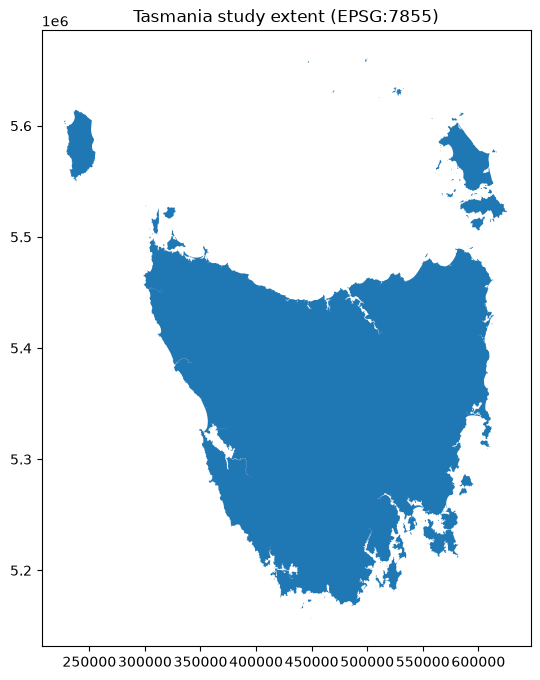

In [2]:
coastline_file = raw / "STE_2021_AUST_SHP_GDA2020/STE_2021_AUST_GDA2020.shp"

gdf = gpd.read_file(str(coastline_file))
tasmania = gdf[gdf["STE_NAME21"] == "Tasmania"].to_crs(TARGET_CRS)

tasmania.to_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg", driver="GPKG")

tasmania.plot(figsize=(8, 8))
plt.title("Tasmania study extent (EPSG:7855)")
plt.show()

## Mole Creek bounding box

Source: Karst Atlas v3.1, selecting polygons named "Mole Creek" or
"Meander - Western Creek", unioned into a single boundary, then
**buffered by 3 km**.

**Why the buffer:** the raw union of karst polygons covers essentially
100% of its own extent with karst/catchment features (checked directly
during Stage 3 development) — there's no surrounding land left to
represent the catchment context that drains into the karst, or the
land use whose pressure the whole project is trying to measure. A 3 km
buffer is a pragmatic, documented choice (not a true watershed
delineation, which would be more rigorous but more time than this
project affords) — stated here as a limitation, not hidden.

Core karst union area: 710.8 km2
Buffered study area: 1155.3 km2


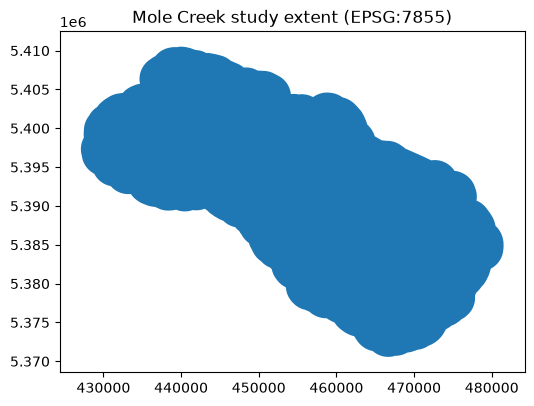

In [3]:
karst_atlas = raw / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp"

gdf = gpd.read_file(str(karst_atlas))
mc_polygons = gdf[
    (gdf["KNAME"].str.contains("Mole Creek", na=False))
    | (gdf["KNAME"] == "Meander - Western Creek")
]

mole_creek_core = gpd.GeoSeries([mc_polygons.geometry.union_all()], crs=gdf.crs).to_crs(TARGET_CRS)

MOLE_CREEK_BUFFER_M = 3000  # 3 km -- see markdown above for why
mole_creek = mole_creek_core.buffer(MOLE_CREEK_BUFFER_M)
mole_creek_gdf = gpd.GeoDataFrame(geometry=mole_creek, crs=TARGET_CRS)

print(f"Core karst union area: {mole_creek_core.area.sum() / 1e6:.1f} km2")
print(f"Buffered study area: {mole_creek_gdf.area.sum() / 1e6:.1f} km2")
mole_creek_gdf.to_file(outpath / "mole_creek_bounding_box_EPSG7855.gpkg", driver="GPKG")

mole_creek_gdf.plot(figsize=(6, 6))
plt.title("Mole Creek study extent (EPSG:7855)")
plt.show()

## Outputs

- `tasmania_bounding_box_EPSG7855.gpkg`
- `mole_creek_bounding_box_EPSG7855.gpkg`

Both in EPSG:7855, ready for Stage 1.